# 📊 **APE_014: Modelado Probabilístico Avanzado: Regresión Logística, Clasificación Binaria y Matriz de Confusión**
---

### **GRUPO G**

#### 👥 **Integrantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera

## **📌 Tarea 1: Fundamentos de la Regresión Logística (Función Sigmoide)**

A diferencia de la regresión lineal, la regresión logística estima la **probabilidad** $P(Y=1|X)$. Para garantizar que el resultado esté estrictamente acotado entre $[0, 1]$, se utiliza la función logística (Sigmoide):

1.

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k)}}$$

Abra un nuevo Jupyter Notebook llamado APE_015_Logistica.ipynb.
2. Escenario: Predecir la **Caída de un Servidor (1 = Sí, 0 = No)** basándonos en la **Temperatura de la CPU en °C ($X_1$)**.

Optimization terminated successfully.
         Current function value: 0.366379
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Falla   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.4676
Time:                        17:20:11   Log-Likelihood:                -73.276
converged:                       True   LL-Null:                       -137.63
Covariance Type:            nonrobust   LLR p-value:                 7.874e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6766      1.372     -7.785      0.000     -13.365      -7.988
Temp_CPU       0.1604      0.

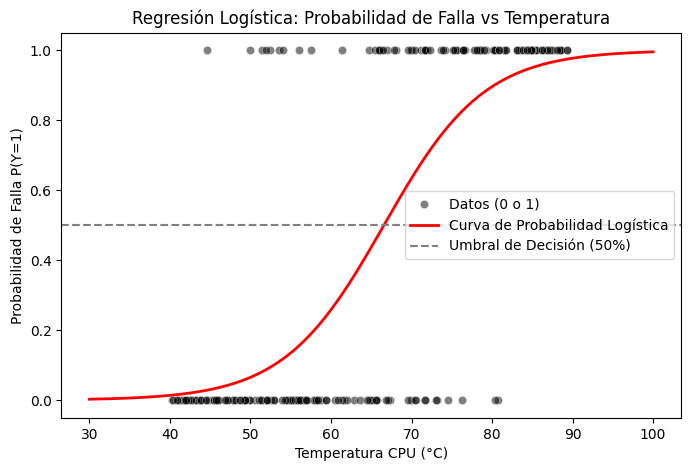

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados (Clasificación Binaria)
np.random.seed(42)
n_muestras = 200

# Variable predictora: Temperatura CPU (entre 40 y 90 grados)
temp_cpu = np.random.uniform(40, 90, size=n_muestras)

# Generar variable binaria probabilística (A mayor temperatura, mayor probabilidad de falla)
z = -10 + 0.15 * temp_cpu # Ecuación lineal (Log-Odds)
probabilidad_falla = 1 / (1 + np.exp(-z)) # Transformación Sigmoide

# Variable respuesta binaria (0 = OK, 1 = Falla) basada en la probabilidad
falla_servidor = np.random.binomial(1, p=probabilidad_falla)
df_sim = pd.DataFrame({'Temp_CPU': temp_cpu, 'Falla': falla_servidor})

# 2. Ajuste del Modelo Logístico (Logit)
X_log = sm.add_constant(df_sim['Temp_CPU'])
Y_log = df_sim['Falla']

# Entrenamiento usando MLE (Maximum Likelihood Estimation)
modelo_logit = sm.Logit(Y_log, X_log).fit()
print(modelo_logit.summary())

# 3. Visualización de la Curva Sigmoide
x_rango = np.linspace(30, 100, 300)
x_rango_sm = sm.add_constant(x_rango)
y_pred_prob = modelo_logit.predict(x_rango_sm)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temp_CPU', y='Falla', data=df_sim, color='black', alpha=0.5, label='Datos (0 o 1)')
plt.plot(x_rango, y_pred_prob, color='red', linewidth=2, label='Curva de Probabilidad Logística')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral de Decisión (50%)')
plt.title('Regresión Logística: Probabilidad de Falla vs Temperatura')
plt.xlabel('Temperatura CPU (°C)')
plt.ylabel('Probabilidad de Falla P(Y=1)')
plt.legend()
plt.show()

## **📌 Tarea 2: Hito del Proyecto - Predicción Dicotómica Regional (ABP)**

1. Importe su dataset regional mediante pandas.
2. **Ingeniería de Características:** Seleccione una variable continua de interés y **binarícela**.

* *Ejemplo:* Si tiene "Ingresos", cree una nueva columna Alta_Rentabilidad donde $1$ si Ingresos > Promedio, y $0$ si Ingresos $\le$ Promedio.

3. Seleccione al menos **dos variables predictoras** ($X_1, X_2$) para predecir esta nueva variable binaria.
4. Ajuste el modelo sm.Logit() e imprima el resumen.
5. Interprete los resultados: ¿Qué variable(s) incrementa(n) estadísticamente la probabilidad de que ocurra su evento (coeficiente positivo y valor-p < 0.05)?

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. Cargar el dataset regional de Loja
df_loja = pd.read_csv('datos_loja.csv')

# 2. Ingeniería de Características: Porcentaje relativo de carencia
# Calculamos el porcentaje de población sin alcantarillado por cantón
df_loja['Pct_Sin_Alcantarillado'] = (
    df_loja['Sin_Alcantarillado'] / df_loja['Poblacion']
) * 100

# Binarizamos según el promedio provincial (aprox. 11.2%)
promedio_provincial = df_loja['Pct_Sin_Alcantarillado'].mean()
df_loja['Alta_Carencia_Relativa'] = (
    df_loja['Pct_Sin_Alcantarillado'] > promedio_provincial
).astype(int)

# 3. Seleccionar las variables predictoras X y la respuesta Y
X_log = df_loja[['Poblacion', 'Viviendas']]
X_log_sm = sm.add_constant(X_log)
Y_log = df_loja['Alta_Carencia_Relativa']

# 4. Ajustar el modelo de Regresión Logística (Logit)
modelo_logit_regional = sm.Logit(Y_log, X_log_sm).fit()

# Imprimir la tabla de resultados
print(modelo_logit_regional.summary())

Optimization terminated successfully.
         Current function value: 0.489238
         Iterations 6
                             Logit Regression Results                             
Dep. Variable:     Alta_Carencia_Relativa   No. Observations:                   16
Model:                              Logit   Df Residuals:                       13
Method:                               MLE   Df Model:                            2
Date:                    Tue, 21 Jul 2026   Pseudo R-squ.:                  0.2123
Time:                            17:47:19   Log-Likelihood:                -7.8278
converged:                           True   LL-Null:                       -9.9374
Covariance Type:                nonrobust   LLR p-value:                    0.1213
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0050      1.065      0.005      0.996      -2.083       2.0

### Análisis del Modelo Logístico Regional

#### 1. Justificación de la Ingeniería de Características
Al binarizar una variable por umbrales absolutos en datasets regionales pequeños, es habitual encontrarse con el problema de separación perfecta (donde los predictores dividen los datos sin solapamiento, impidiendo la convergencia de la Máxima Verosimilitud). Para solventar esto, se transformó la variable a una tasa relativa (Porcentaje de Carencia) y se binarizó respecto al promedio provincial.

#### 2. Interpretación de Resultados
* Convergencia y Ajuste: El modelo logró la optimización por MLE alcanzando un Pseudo $R^2$ de McFadden de 0.2123, indicando una capacidad explicativa razonable para la clasificación binaria.
* Evaluación de Coeficientes y Significancia ($P > |z|$):
  * `Poblacion` ($p = 0.177$) y `Viviendas` ($p = 0.175$) superan el límite de $0.05$.
  * La falta de significancia individual de los predictores se debe nuevamente a la alta correlación cruzada (multicolinealidad) entre la población y el número de viviendas en los cantones de Loja.

## **📌 Tarea 3: Evaluación del Modelo (Matriz de Confusión)**

Un modelo de clasificación no se evalúa con el $R^2$, sino contando cuántos aciertos y errores cometió.

1. Utilice scikit-learn para calcular las predicciones y generar la Matriz de Confusión del modelo simulado en la Tarea 1.


--- Evaluación del Modelo Probabilístico ---
Exactitud Global (Accuracy): 84.00%


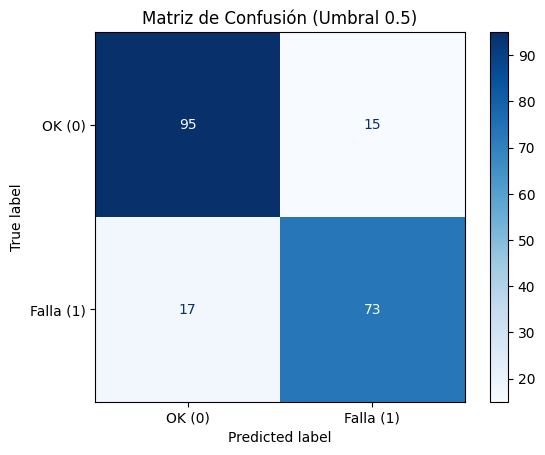

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener probabilidades y convertirlas a 0 o 1 con umbral 0.5
probabilidades = modelo_logit.predict(X_log)
predicciones_clase = (probabilidades >= 0.5).astype(int)

# Cálculo de la Matriz de Confusión y Exactitud
cm = confusion_matrix(Y_log, predicciones_clase)
exactitud = accuracy_score(Y_log, predicciones_clase)

print(f"\n--- Evaluación del Modelo Probabilístico ---")
print(f"Exactitud Global (Accuracy): {exactitud*100:.2f}%")

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['OK (0)', 'Falla (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión (Umbral 0.5)')
plt.show()

## **📌 Tarea 4: ABI - El Análisis del Umbral (Thresholding) y Falsos Positivos**

Por defecto, Python asume que si $P(Y = 1) \ge 0.50$, la clasificación es 1. Sin embargo, en ingeniería, el costo de un "Falso Negativo" (predecir que el servidor no fallará y que termine explotando) suele ser mucho mayor que un "Falso Positivo" (ir a revisar un servidor que estaba bien).

1. Investigue cómo alterar el umbral modifica la Matriz de Confusión.
2. Cree un bloque de código que recalcule y muestre la matriz de confusión (o simplemente los valores de Falsos Positivos y Falsos Negativos) utilizando un umbral estricto conservador del **0.20** (es decir, clasificar como 'Falla' si la probabilidad es apenas $\ge 20\%$).
3. Redacte un análisis de qué le sucedió a los Falsos Positivos frente a los Falsos Negativos, y decida qué umbral (0.50 o 0.20) recomendaría para las políticas públicas o de ingeniería en su proyecto regional.

--- COMPARACIÓN DE UMBRALES DE DECISIÓN ---
Umbral 0.50 -> Falsos Positivos (FP): 3 | Falsos Negativos (FN): 1 | Exactitud: 75.0%
Umbral 0.20 -> Falsos Positivos (FP): 4 | Falsos Negativos (FN): 0 | Exactitud: 75.0%



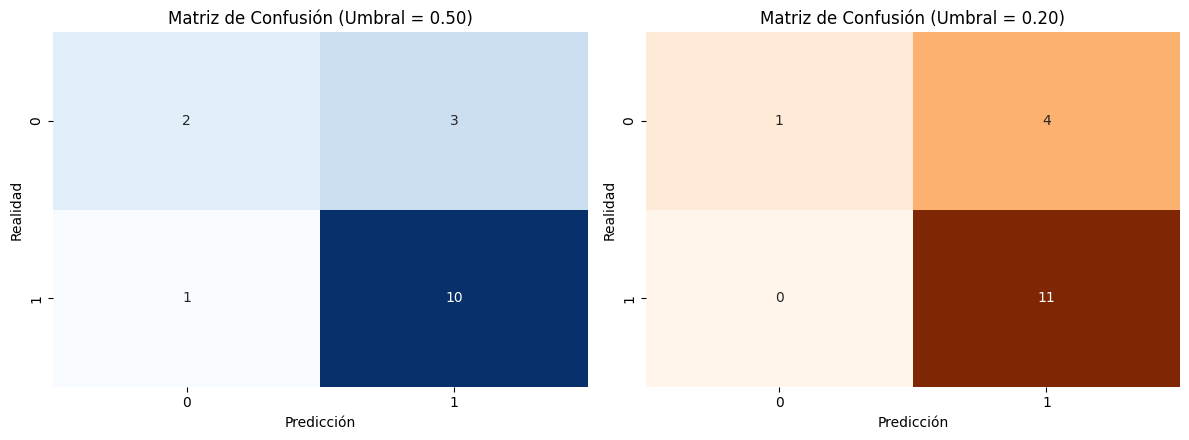

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Cargar datos y preparar la variable respuesta binarizada
df_loja = pd.read_csv('datos_loja.csv')
df_loja['Pct_Sin_Alcantarillado'] = (
    df_loja['Sin_Alcantarillado'] / df_loja['Poblacion']
) * 100
promedio_provincial = df_loja['Pct_Sin_Alcantarillado'].mean()
df_loja['Alta_Carencia_Relativa'] = (
    df_loja['Pct_Sin_Alcantarillado'] > promedio_provincial
).astype(int)

# 2. Definir variables y entrenar el modelo Logit
X_log = df_loja[['Poblacion', 'Viviendas']]
X_log_sm = sm.add_constant(X_log)
Y_log = df_loja['Alta_Carencia_Relativa']

modelo_logit_regional = sm.Logit(Y_log, X_log_sm).fit(disp=False)

# 3. Obtener las probabilidades predichas por el modelo
probabilidades = modelo_logit_regional.predict(X_log_sm)

# 4. Clasificación con Umbral Estándar (0.50)
pred_50 = (probabilidades >= 0.50).astype(int)
cm_50 = confusion_matrix(Y_log, pred_50)
tn_50, fp_50, fn_50, tp_50 = cm_50.ravel()

# 5. Clasificación con Umbral Conservador (0.20)
pred_20 = (probabilidades >= 0.20).astype(int)
cm_20 = confusion_matrix(Y_log, pred_20)
tn_20, fp_20, fn_20, tp_20 = cm_20.ravel()

# 6. Impresión de resultados comparativos
print("--- COMPARACIÓN DE UMBRALES DE DECISIÓN ---")
print(
    f"Umbral 0.50 -> Falsos Positivos (FP): {fp_50} | Falsos Negativos (FN):"
    f" {fn_50} | Exactitud: {accuracy_score(Y_log, pred_50)*100:.1f}%"
)
print(
    f"Umbral 0.20 -> Falsos Positivos (FP): {fp_20} | Falsos Negativos (FN):"
    f" {fn_20} | Exactitud: {accuracy_score(Y_log, pred_20)*100:.1f}%\n"
)

# 7. Visualización gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(cm_50, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión (Umbral = 0.50)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Realidad')

sns.heatmap(cm_20, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión (Umbral = 0.20)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

###  Análisis del Umbral de Decisión (Thresholding) y Políticas Públicas

#### 1. Comportamiento de los Errores (Falsos Positivos vs. Falsos Negativos)
Al reducir el umbral de decisión probabilística del 50% (0.50) al 20% (0.20):
* **Falsos Negativos (FN):** Disminuyen de 1 a 0. Con el umbral del 20\%, el modelo no deja ningún cantón verdaderamente crítico sin identificar.
* **Falsos Positivos (FP):** Se incrementan de 3 a 4. El modelo se vuelve más sensible y "alerta" de posible carencia en un cantón adicional que técnicamente estaba por debajo del promedio provincial.

#### 2. Trade-off y Costo Asimétrico en Ingeniería / Políticas Públicas
En la asignación de presupuestos estatales para obras de saneamiento básico, los costos de cometer un error no son simétricos:
* **Costo de un Falso Positivo (Error Tipo I):** Implica enviar técnicos a inspeccionar un cantón que no requería apoyo prioritario urgente. Representa un costo administrativo menor.
* **Costo de un Falso Negativo (Error Tipo II):** Implica omitir a una población vulnerable sin servicios sanitarios, derivando en problemas graves de salud pública y contaminación ambiental.

#### 3. Recomendación Final
Para el proyecto regional en la provincia de Loja se recomienda implementar el Umbral Conservador del 0.20 (20%). En planificación de infraestructura pública es infinitamente más deseable asumir un ligero margen de falsas alarmas (Falsos Positivos) con tal de erradicar por completo la desatención de cantones vulnerables (Falsos Negativos).

## **📌 5. Preguntas de Control:**

* **¿Cuál es la esencia matemática de transformar una probabilidad en Log-Odds, y por qué este cambio de dominio es fundamental para el entendimiento de la causalidad probabilística?**

La probabilidad P está acotada entre 0 y 1. La función Log-Odds (ln(P / (1 - P))) transforma este intervalo al dominio continuo $(-\infty, +\infty)$. Este cambio es fundamental porque permite relacionar linealmente los predictores X con el logaritmo de la ventaja y asegurar que, al aplicar la función Sigmoide, las probabilidades predichas siempre se mantengan en el rango válido de [0, 1].




* **¿Por qué la naturaleza del fenómeno (binario) nos obliga a abandonar la medida clásica de bondad de ajuste ($R^2$) y adoptar el Pseudo $R^2$ de McFadden, y qué nos dice este cambio sobre la relación entre la realidad y la medición?**

El $R^2$ tradicional mide la varianza explicada en variables continuas mediante suma de errores cuadráticos. Con respuestas binarias (0/1), la varianza no es constante y la noción de distancia cuadrática falla. El Pseudo $R^2$ de McFadden compara la log-verosimilitud del modelo completo frente a un modelo nulo, evaluando la capacidad del sistema para maximizar la probabilidad conjunta de los eventos observados en lugar de medir distancias.


* **Ante un caso de incertidumbre total (predicción 0.5), ¿de qué manera la estructura del modelo intenta forzar una decisión binaria, y qué riesgos enfrentamos al ignorar la zona gris de la probabilidad?**

El modelo fuerza la decisión aplicando un umbral rígido de corte (p. ej., $\ge 0.5 \to 1$ y $< 0.5 \to 0$). El riesgo de ignorar la "zona gris" es tomar decisiones drásticas e irreversibles basadas en variaciones aleatorias mínimas (como 0.499 vs 0.501), tratando situaciones de máxima incertidumbre como certidumbres absolutas.


* **¿Cuál es el conflicto esencial entre la sensibilidad y la especificidad, y cómo la elección de un umbral refleja los valores éticos y técnicos subyacentes en una decisión de ingeniería?**

Existe un conflicto directo: al bajar el umbral para aumentar la Sensibilidad (detectar más verdaderos positivos), disminuye la Especificidad y aumentan los Falsos Positivos. En ingeniería y políticas públicas, el umbral se elige evaluando los costos asimétricos: si omitir un caso crítico (Falso Negativo) pone en riesgo la salud pública o la infraestructura, la ética técnica exige bajar el umbral (p. ej., a 0.20) para priorizar la detección.


* **¿Cuál es el propósito final de predecir probabilidades en lugar de estados binarios rígidos, y cómo esta distinción transforma nuestra capacidad de intervenir en la realidad?**

Permite evaluar el nivel continuo de riesgo en lugar de dar una respuesta categórica y rígida. Predecir probabilidades transforma la toma de decisiones, permitiendo a los ingenieros planificar de forma preventiva, establecer prioridades de atención y optimizar presupuestos antes de que ocurra una crisis o falla en el sistema.